In [1]:
import pandas as pd

# Direct download URL for the parquet file
url = (
    "https://huggingface.co/datasets/ComplexDataLab/Misinfo_Datasets/"
    "resolve/ec9879b348758e813c3e7bc37d052fab731c239a/"
    "fakenewsamt/fakenewsamt_test.parquet"
)

# Load the parquet file directly from URL
df = pd.read_parquet(url)

print(f"Total rows: {len(df)}")
print(f"Columns: {df.columns.tolist()}")
print(df.head())

# Sample up to 15k rows (or all rows if fewer than 15k)
n = min(15_000, len(df))
sample_df = df.sample(n=n, random_state=42)

# Save to CSV
output_path = "fakenewsamt_sample.csv"
sample_df.to_csv(output_path, index=False)

print(f"\nSaved {n} rows to {output_path}")

Total rows: 96
Columns: ['claim', 'veracity', 'dataset', 'label', 'question', 'answer', 'positive_evidence_text', 'positive_evidence_title', 'negative_evidence_text', 'negative_evidence_title', 'split', 'source', 'source_url', 'article_content', 'scraped_at', 'inserted_at', 'updated_at', 'article_headline', 'author', 'meta_keywords', 'meta_description', 'tags', 'initial_claim', 'fact1', 'fact2', 'fact3', 'fact4', 'num_hops', 'date', 'similarity', 'like_count', 'retweet_count', 'tweet_text', 'tweet_label', 'hashtag', 'evidence_1', 'link_evidence_1', 'source_evidence_1', 'fact_check_source', 'image', 'author_2', 'article_title', 'meta_data_description', 'meta_data_keywords', 'meta_data_date', 'meta_data_journal', 'meta_data_type', 'meta_data_institution', 'meta_data_region', 'meta_data_twitter_site', 'meta_data_twitter_creator', 'meta_data_twitter_domain', 'meta_data_twitter_title', 'meta_data_twitter_description', 'meta_data_twitter_image', 'meta_data_twitter_url', 'meta_data_og_title',

In [4]:
# Replace string "na" with actual NaN, then recheck
df = df.replace("na", pd.NA)

na_pct = df.isna().mean() * 100
high_na_cols = na_pct[na_pct > 70].sort_values(ascending=False)

print(f"Columns with >90% NA values: {len(high_na_cols)}\n")
print(high_na_cols.to_string())

Columns with >90% NA values: 227

claim                                     100.0
excl_thread                               100.0
writer_intent                             100.0
effect_on_reader                          100.0
reader_action                             100.0
spread                                    100.0
pred_label                                100.0
related_tweet                             100.0
5_label_majority_answer                   100.0
3_label_majority_answer                   100.0
comments                                  100.0
crawled                                   100.0
domain_rank                               100.0
likes                                     100.0
ord_in_thread                             100.0
participants_count                        100.0
replies_count                             100.0
shares                                    100.0
spam_score                                100.0
thread_title                              100.0
uuid  

In [5]:
df_clean = df.drop(columns=high_na_cols.index)
df_clean = df_clean.dropna()

print(f"Original shape: {df.shape}")
print(f"Cleaned shape:  {df_clean.shape}")

Original shape: (96, 233)
Cleaned shape:  (84, 6)


In [6]:
df = df_clean

print(f"Total rows: {len(df)}")
print(f"Columns: {df.columns.tolist()}")
print(df.head())

# Sample up to 15k rows (or all rows if fewer than 15k)
n = min(15_000, len(df))
sample_df = df.sample(n=n, random_state=42)

# Save to CSV
output_path = "fakenewsamt_sampl_clean.csv"
sample_df.to_csv(output_path, index=False)

print(f"\nSaved {n} rows to {output_path}")

Total rows: 84
Columns: ['veracity', 'dataset', 'label', 'split', 'article_content', 'article_headline']
      veracity      dataset label split  \
11973    false  fakenewsamt  fake  test   
11974    false  fakenewsamt  fake  test   
11975    false  fakenewsamt  fake  test   
11976    false  fakenewsamt  fake  test   
11977    false  fakenewsamt  fake  test   

                                         article_content  \
11973  \r\ngovernment and silicon valley are looking ...   
11974  \r\nsetting up face-off with trump "california...   
11975  "the negotiations we are going great according...   
11976  \r\n"brewdog was recently found to include dog...   
11977  \r\n"european union regulators applauded deuts...   

                                        article_headline  
11973                            the big data conspiracy  
11974  california surprisingly lenient on auto emissi...  
11975  brexit talks are seeing success: josé manuel b...  
11976  brewdog under fire for accusatio

In [7]:
import pandas as pd
import os

files = {
    "BuzzFeed_fake": "./archive/BuzzFeed_fake_news_content.csv",
    "BuzzFeed_real": "./archive/BuzzFeed_real_news_content.csv",
    "PolitiFact_fake": "./archive/PolitiFact_fake_news_content.csv",
    "PolitiFact_real": "./archive/PolitiFact_real_news_content.csv",
}

COLS_TO_DROP = ["id", "top_img", "authors", "publish_date", "movies", "images"]

dfs = []
for name, filename in files.items():
    df = pd.read_csv(filename)
    
    # Add source and label columns from filename
    df["source"]  = name.split("_")[0]           # BuzzFeed or PolitiFact
    df["label"]   = "fake" if "fake" in name else "real"
    
    # Drop unwanted columns (ignore if missing)
    df = df.drop(columns=[c for c in COLS_TO_DROP if c in df.columns])
    
    # Create combined full_text column
    title = df["title"].fillna("")
    text  = df["text"].fillna("")
    df["full_text"] = title + ". " + text
    df["full_text"] = df["full_text"].str.strip(". ").str.strip()
    
    # Drop rows where full_text is essentially empty
    df = df[df["full_text"].str.len() > 20]
    
    dfs.append(df)
    print(f"{name}: {len(df)} rows, columns: {df.columns.tolist()}")

# Save individual cleaned CSVs
for (name, _), df in zip(files.items(), dfs):
    out = f"{name}_cleaned.csv"
    df.to_csv(out, index=False)
    print(f"Saved {out}")

# Save one combined CSV with everything
combined = pd.concat(dfs, ignore_index=True)
combined.to_csv("fakenewsnet_combined_cleaned.csv", index=False)
print(f"\nCombined dataset: {combined.shape}")
print(combined[["source", "label"]].value_counts())

BuzzFeed_fake: 91 rows, columns: ['title', 'text', 'url', 'source', 'canonical_link', 'meta_data', 'label', 'full_text']
BuzzFeed_real: 91 rows, columns: ['title', 'text', 'url', 'source', 'canonical_link', 'meta_data', 'label', 'full_text']
PolitiFact_fake: 120 rows, columns: ['title', 'text', 'url', 'source', 'canonical_link', 'meta_data', 'label', 'full_text']
PolitiFact_real: 120 rows, columns: ['title', 'text', 'url', 'source', 'canonical_link', 'meta_data', 'label', 'full_text']
Saved BuzzFeed_fake_cleaned.csv
Saved BuzzFeed_real_cleaned.csv
Saved PolitiFact_fake_cleaned.csv
Saved PolitiFact_real_cleaned.csv

Combined dataset: (422, 8)
source      label
PolitiFact  fake     120
            real     120
BuzzFeed    fake      91
            real      91
Name: count, dtype: int64


In [13]:
combined.iloc[1]

title             Charity: Clinton Foundation Distributed “Water...
text              Former President Bill Clinton and his Clinton ...
url               http://eaglerising.com/36899/charity-clinton-f...
source                                                     BuzzFeed
canonical_link    http://eaglerising.com/36899/charity-clinton-f...
meta_data         {"description": "The possibility that CHAI dis...
label                                                          fake
full_text         Charity: Clinton Foundation Distributed “Water...
Name: 1, dtype: str

In [ ]:
from llama_cpp import Llama
import numpy as np
import pandas as pd
from tqdm import tqdm

llm = Llama(
    model_path="./emollama_gguf/Emollama-7b.Q4_K_M.gguf",
    n_ctx=2048,
    n_gpu_layers=-1,  # full Metal GPU on M4
    verbose=False
)

# ─────────────────────────────────────────
# PROMPT TEMPLATES (exact format from paper)
# ─────────────────────────────────────────

def prompt_vreg(text: str) -> str:
    """Sentiment strength — Vreg — best retrieval signal per paper"""
    return (
        f"Human:\nTask: Evaluate the valence intensity of the writer's mental state "
        f"based on the text, assigning it a real-valued score from 0 (most negative) "
        f"to 1 (most positive).\nText: {text}\nIntensity Score:\n\nA:\n>>"
    )

def prompt_voc(text: str) -> str:
    """Sentiment classification — Voc"""
    return (
        f"Human:\nTask: Categorize the text into an ordinal class that best characterizes "
        f"the writer's mental state, considering various degrees of positive and negative "
        f"sentiment intensity. 3: very positive mental state can be inferred. "
        f"2: moderately positive mental state can be inferred. "
        f"1: slightly positive mental state can be inferred. "
        f"0: neutral or mixed mental state can be inferred. "
        f"-1: slightly negative mental state can be inferred. "
        f"-2: moderately negative mental state can be inferred. "
        f"-3: very negative mental state can be inferred\n"
        f"Text: {text}\nIntensity Class:\n\nA:\n>>"
    )

def prompt_eireg(text: str, emotion: str) -> str:
    """Emotion intensity — EIreg — one call per emotion (anger/fear/joy/sadness)"""
    return (
        f"Human:\nTask: Assign a numerical value between 0 (least E) and 1 (most E) "
        f"to represent the intensity of emotion E expressed in the text.\n"
        f"Text: {text}\nEmotion: {emotion}\nIntensity Score:\n\nA:\n>>"
    )

def prompt_ec(text: str) -> str:
    """Emotion detection — Ec"""
    return (
        f"Human:\nTask: Categorize the text's emotional tone as either "
        f"'neutral or no emotion' or identify the presence of one or more of the given "
        f"emotions (anger, anticipation, disgust, fear, joy, love, optimism, pessimism, "
        f"sadness, surprise, trust).\nText: {text}\nThis text contains emotions:\n\nA:\n>>"
    )

# ─────────────────────────────────────────
# GENERATE + PARSE HELPERS
# ─────────────────────────────────────────

def generate(prompt: str, max_tokens: int = 20) -> str:
    out = llm(prompt, max_tokens=max_tokens, temperature=0, echo=False)
    return out["choices"][0]["text"].strip()

def parse_float(raw: str, default: float = 0.5) -> float:
    """Extract first float found in output"""
    import re
    matches = re.findall(r"[-+]?\d*\.?\d+", raw)
    if matches:
        return max(0.0, min(1.0, float(matches[0])))
    return default

def parse_voc(raw: str) -> int:
    """Extract integer from -3 to 3"""
    import re
    matches = re.findall(r"-?\d+", raw)
    if matches:
        return max(-3, min(3, int(matches[0])))
    return 0

def parse_ec(raw: str) -> list:
    """Extract emotion labels from output"""
    emotions = ["anger","anticipation","disgust","fear","joy",
                "love","optimism","pessimism","sadness","surprise","trust"]
    return [e for e in emotions if e in raw.lower()]

# ─────────────────────────────────────────
# FULL AFFECTIVE PROFILE PER ARTICLE
# ─────────────────────────────────────────

def get_affective_profile(text: str) -> dict:
    """
    Returns all 5 affective dimensions for one article.
    This is what gets stored in your retrieval database.
    """
    text_short = text[:350]  # truncate to fit context window

    # Vreg — sentiment strength (PRIMARY retrieval signal)
    vreg_raw = generate(prompt_vreg(text_short))
    vreg     = parse_float(vreg_raw)

    # Voc — sentiment class
    voc_raw  = generate(prompt_voc(text_short))
    voc      = parse_voc(voc_raw)

    # EIreg — emotion intensity x4
    eireg = {}
    for emotion in ["anger", "fear", "joy", "sadness"]:
        raw = generate(prompt_eireg(text_short, emotion))
        eireg[emotion] = parse_float(raw)

    # Ec — emotion detection
    ec_raw = generate(prompt_ec(text_short), max_tokens=30)
    ec     = parse_ec(ec_raw)

    return {
        "vreg":         vreg,           # float 0-1
        "voc":          voc,            # int -3 to 3
        "eireg_anger":  eireg["anger"], # float 0-1
        "eireg_fear":   eireg["fear"],
        "eireg_joy":    eireg["joy"],
        "eireg_sadness":eireg["sadness"],
        "ec":           ec,             # list of emotion strings
    }

# ─────────────────────────────────────────
# GET IMPLICIT EMBEDDINGS (last hidden layer)
# Switch model to embedding mode
# ─────────────────────────────────────────

llm_embed = Llama(
    model_path="./emollama_gguf/Emollama-7b.Q4_K_M.gguf",
    embedding=True,   # embedding mode — different from generation mode
    n_ctx=2048,
    n_gpu_layers=-1,
    verbose=False
)

def get_embedding(text: str) -> np.ndarray:
    """Implicit affective embedding from last hidden layer"""
    return np.array(llm_embed.embed(text[:350]))

# ─────────────────────────────────────────
# RUN ON YOUR DATASETxqx
# ─────────────────────────────────────────

df = pd.read_csv("fakenewsnet_combined_cleaned.csv")

profiles = []
embeddings = []

for i, row in tqdm(df.iterrows(), total=len(df)):
    try:
        text = row["full_text"]

        # explicit affect scores
        profile = get_affective_profile(text)
        profiles.append(profile)

        # implicit embedding
        emb = get_embedding(text)
        embeddings.append(emb)

        # save checkpoint every 50 rows (in case it crashes)
        if i % 50 == 0 and i > 0:
            pd.DataFrame(profiles).to_csv("profiles_checkpoint.csv", index=False)
            np.save("embeddings_checkpoint.npy", np.vstack(embeddings))
        
        print(profile)
    except Exception as e:
        print("Exception : ", e)
        break
    
# Save final outputs
profiles_df = pd.DataFrame(profiles)
df_final = pd.concat([df.reset_index(drop=True), profiles_df], axis=1)
df_final.to_csv("fakenewsnet_with_affect_latest.csv", index=False)
np.save("affective_embeddings.npy", np.vstack(embeddings))

print(f"Done. Shape: {df_final.shape}")
print(df_final[["label", "vreg", "eireg_anger", "eireg_fear", "eireg_joy"]].groupby("label").mean())

  0%|          | 1/422 [00:16<1:54:55, 16.38s/it]

{'vreg': 0.322, 'voc': 0, 'eireg_anger': 0.428, 'eireg_fear': 0.42, 'eireg_joy': 0.22, 'eireg_sadness': 0.428, 'ec': ['anger', 'disgust']}


  0%|          | 2/422 [00:32<1:53:41, 16.24s/it]

{'vreg': 0.483, 'voc': 0, 'eireg_anger': 0.438, 'eireg_fear': 0.42, 'eireg_joy': 0.16, 'eireg_sadness': 0.438, 'ec': []}


  1%|          | 3/422 [00:47<1:50:04, 15.76s/it]

...

{'vreg': 0.32, 'voc': -2, 'eireg_anger': 0.425, 'eireg_fear': 0.396, 'eireg_joy': 0.22, 'eireg_sadness': 0.396, 'ec': ['anger', 'disgust']}


 72%|███████▏  | 302/422 [1:20:43<35:32, 17.77s/it]

{'vreg': 0.45, 'voc': 0, 'eireg_anger': 0.458, 'eireg_fear': 0.5, 'eireg_joy': 0.18, 'eireg_sadness': 0.417, 'ec': []}


 72%|███████▏  | 302/422 [1:20:53<32:08, 16.07s/it]


KeyboardInterrupt: 

In [2]:
import csv 

with open("./ready_data.csv") as f:
    data = []
    reader = csv.reader(f)
    for r in reader:
        data.append(r)

In [6]:
print(data[0])

['title', 'text', 'url', 'source', 'canonical_link', 'meta_data', 'label', 'full_text', 'vreg', 'voc', 'eireg_anger', 'eireg_fear', 'eireg_joy', 'eireg_sadness', 'ec']


Matplotlib is building the font cache; this may take a moment.


LABEL DISTRIBUTION
label
fake    211
real    211
Name: count, dtype: int64

MEAN AFFECT SCORES BY LABEL
         vreg     voc  eireg_anger  eireg_fear  eireg_joy  eireg_sadness
label                                                                   
fake   0.4530  0.0332       0.4363      0.4526     0.2262          0.397
real   0.4649  0.0474       0.4080      0.4338     0.2385          0.384

T-TEST: FAKE vs REAL (replicating paper Table 2)
vreg                 | real=0.4649  fake=0.4530 | t=1.7056  p=8.88e-02  ✗ not significant
voc                  | real=0.0474  fake=0.0332 | t=0.5627  p=5.74e-01  ✗ not significant
eireg_anger          | real=0.4080  fake=0.4363 | t=-4.5834  p=6.04e-06  ✓ SIGNIFICANT
eireg_fear           | real=0.4338  fake=0.4526 | t=-2.5082  p=1.25e-02  ✓ SIGNIFICANT
eireg_joy            | real=0.2385  fake=0.2262 | t=1.7999  p=7.26e-02  ✗ not significant
eireg_sadness        | real=0.3840  fake=0.3970 | t=-1.8439  p=6.59e-02  ✗ not significant

EMOTION PATTERN CL

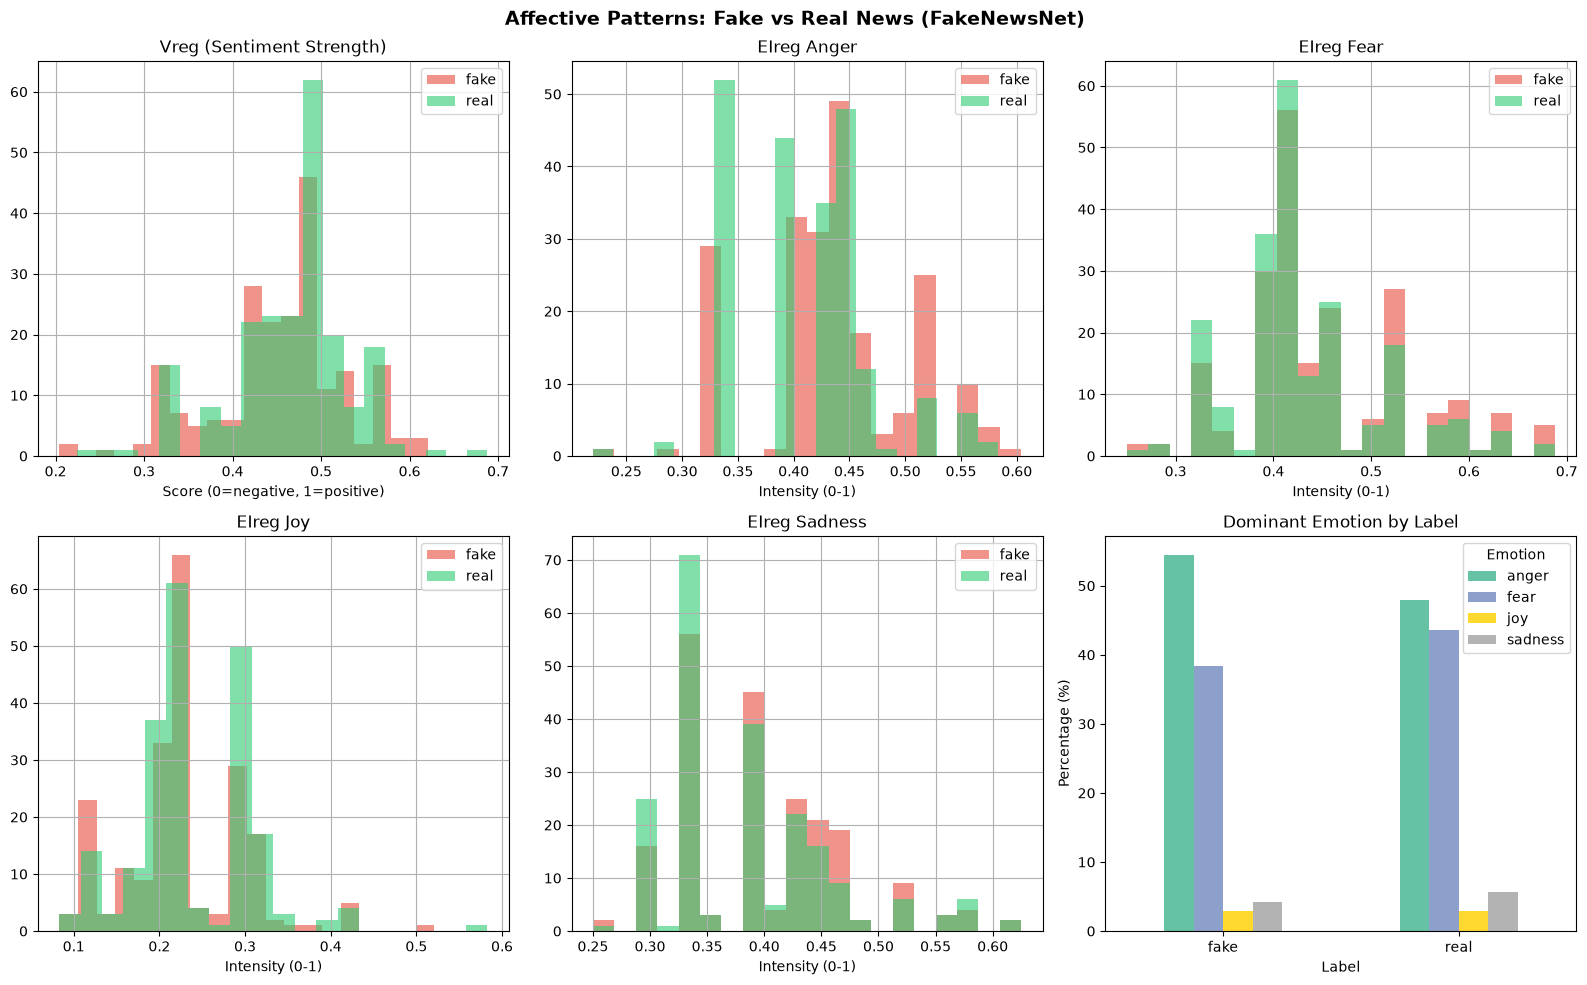


Plot saved to affect_patterns.png


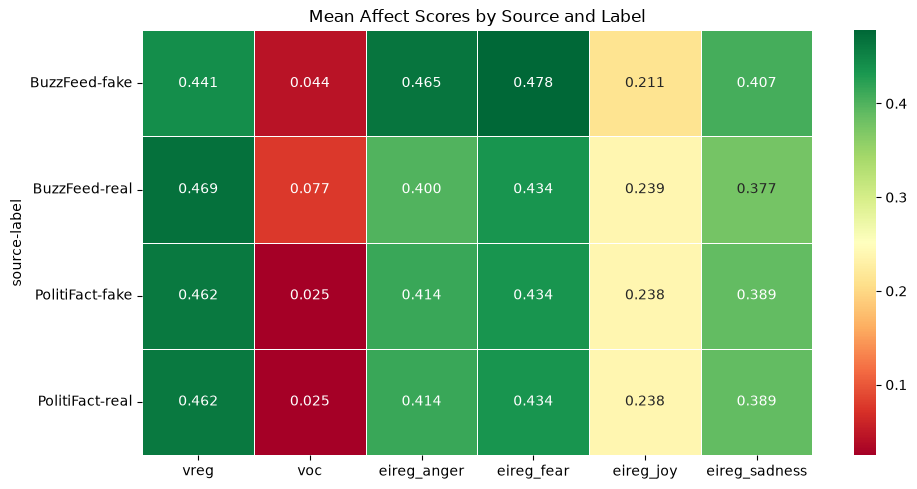

Heatmap saved to affect_heatmap.png


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

df = pd.read_csv("ready_data.csv")

# ─────────────────────────────────────────
# 1. BASIC LABEL DISTRIBUTION
# ─────────────────────────────────────────
print("=" * 50)
print("LABEL DISTRIBUTION")
print("=" * 50)
print(df["label"].value_counts())

# ─────────────────────────────────────────
# 2. MEAN AFFECT SCORES BY LABEL
# ─────────────────────────────────────────
affect_cols = ["vreg", "voc", "eireg_anger", "eireg_fear", "eireg_joy", "eireg_sadness"]

print("\n" + "=" * 50)
print("MEAN AFFECT SCORES BY LABEL")
print("=" * 50)
means = df.groupby("label")[affect_cols].mean().round(4)
print(means)

# ─────────────────────────────────────────
# 3. T-TEST: ARE DIFFERENCES SIGNIFICANT?
# (replicating Table 2 from the paper)
# ─────────────────────────────────────────
print("\n" + "=" * 50)
print("T-TEST: FAKE vs REAL (replicating paper Table 2)")
print("=" * 50)

fake = df[df["label"] == "fake"]
real = df[df["label"] == "real"]

for col in affect_cols:
    t, p = stats.ttest_ind(real[col].dropna(), fake[col].dropna())
    sig = "✓ SIGNIFICANT" if p < 0.05 else "✗ not significant"
    print(f"{col:20s} | real={real[col].mean():.4f}  fake={fake[col].mean():.4f} | t={t:.4f}  p={p:.2e}  {sig}")

# ─────────────────────────────────────────
# 4. EMOTION PATTERN CLUSTERS
# High/low thresholds per emotion per label
# ─────────────────────────────────────────
print("\n" + "=" * 50)
print("EMOTION PATTERN CLUSTERS")
print("=" * 50)

THRESHOLD = 0.5  # above = high, below = low

for label in ["fake", "real"]:
    subset = df[df["label"] == label]
    print(f"\n--- {label.upper()} ({len(subset)} articles) ---")
    for col in ["eireg_anger", "eireg_fear", "eireg_joy", "eireg_sadness"]:
        high = (subset[col] > THRESHOLD).sum()
        low  = (subset[col] <= THRESHOLD).sum()
        pct  = high / len(subset) * 100
        print(f"  {col:20s} | HIGH: {high:4d} ({pct:.1f}%)  LOW: {low:4d} ({100-pct:.1f}%)")

# ─────────────────────────────────────────
# 5. DOMINANT EMOTION PER ARTICLE
# Which single emotion is strongest?
# ─────────────────────────────────────────
emotion_cols = ["eireg_anger", "eireg_fear", "eireg_joy", "eireg_sadness"]
df["dominant_emotion"] = df[emotion_cols].idxmax(axis=1).str.replace("eireg_", "")

print("\n" + "=" * 50)
print("DOMINANT EMOTION DISTRIBUTION BY LABEL")
print("=" * 50)
dom = df.groupby(["label", "dominant_emotion"]).size().unstack(fill_value=0)
print(dom)
print("\nAs percentages:")
print((dom.div(dom.sum(axis=1), axis=0) * 100).round(1))

# ─────────────────────────────────────────
# 6. VREG BUCKETS (negative / neutral / positive)
# ─────────────────────────────────────────
def vreg_bucket(v):
    if v < 0.4:   return "negative"
    elif v < 0.6: return "neutral"
    else:         return "positive"

df["vreg_bucket"] = df["vreg"].apply(vreg_bucket)

print("\n" + "=" * 50)
print("SENTIMENT BUCKET (Vreg) BY LABEL")
print("=" * 50)
vbucket = df.groupby(["label", "vreg_bucket"]).size().unstack(fill_value=0)
print(vbucket)
print("\nAs percentages:")
print((vbucket.div(vbucket.sum(axis=1), axis=0) * 100).round(1))

# ─────────────────────────────────────────
# 7. VISUALISATIONS
# ─────────────────────────────────────────

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("Affective Patterns: Fake vs Real News (FakeNewsNet)", fontsize=14, fontweight="bold")

colors = {"fake": "#e74c3c", "real": "#2ecc71"}

# Plot 1 — Vreg distribution
ax = axes[0, 0]
for label, grp in df.groupby("label"):
    grp["vreg"].hist(ax=ax, alpha=0.6, bins=20, label=label, color=colors[label])
ax.set_title("Vreg (Sentiment Strength)")
ax.set_xlabel("Score (0=negative, 1=positive)")
ax.legend()

# Plot 2 — Anger distribution
ax = axes[0, 1]
for label, grp in df.groupby("label"):
    grp["eireg_anger"].hist(ax=ax, alpha=0.6, bins=20, label=label, color=colors[label])
ax.set_title("EIreg Anger")
ax.set_xlabel("Intensity (0-1)")
ax.legend()

# Plot 3 — Fear distribution
ax = axes[0, 2]
for label, grp in df.groupby("label"):
    grp["eireg_fear"].hist(ax=ax, alpha=0.6, bins=20, label=label, color=colors[label])
ax.set_title("EIreg Fear")
ax.set_xlabel("Intensity (0-1)")
ax.legend()

# Plot 4 — Joy distribution
ax = axes[1, 0]
for label, grp in df.groupby("label"):
    grp["eireg_joy"].hist(ax=ax, alpha=0.6, bins=20, label=label, color=colors[label])
ax.set_title("EIreg Joy")
ax.set_xlabel("Intensity (0-1)")
ax.legend()

# Plot 5 — Sadness distribution
ax = axes[1, 1]
for label, grp in df.groupby("label"):
    grp["eireg_sadness"].hist(ax=ax, alpha=0.6, bins=20, label=label, color=colors[label])
ax.set_title("EIreg Sadness")
ax.set_xlabel("Intensity (0-1)")
ax.legend()

# Plot 6 — Dominant emotion stacked bar
ax = axes[1, 2]
dom_pct = (dom.div(dom.sum(axis=1), axis=0) * 100)
dom_pct.plot(kind="bar", ax=ax, colormap="Set2")
ax.set_title("Dominant Emotion by Label")
ax.set_xlabel("Label")
ax.set_ylabel("Percentage (%)")
ax.tick_params(axis="x", rotation=0)
ax.legend(title="Emotion")

plt.tight_layout()
plt.savefig("affect_patterns.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nPlot saved to affect_patterns.png")

# ─────────────────────────────────────────
# 8. HEATMAP — mean affect by source + label
# ─────────────────────────────────────────
fig2, ax2 = plt.subplots(figsize=(10, 5))
pivot = df.groupby(["source", "label"])[affect_cols].mean().round(3)
sns.heatmap(pivot, annot=True, fmt=".3f", cmap="RdYlGn", ax=ax2, linewidths=0.5)
ax2.set_title("Mean Affect Scores by Source and Label")
plt.tight_layout()
plt.savefig("affect_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Heatmap saved to affect_heatmap.png")

TABLE: Affective Analysis — FakeNewsNet (BuzzFeed + PolitiFact)
Dimension             Real mean   Real var  Fake mean   Fake var        t          p
----------------------------------------------------------------------
Vreg                     0.4649     0.0047     0.4530     0.0056   1.7056   8.88e-02
EIreg-Anger              0.4080     0.0036     0.4363     0.0044  -4.5834   6.04e-06*
EIreg-Fear               0.4338     0.0053     0.4526     0.0066  -2.5082   1.25e-02*
EIreg-Joy                0.2385     0.0048     0.2262     0.0050   1.7999   7.26e-02
EIreg-Sadness            0.3840     0.0054     0.3970     0.0050  -1.8439   6.59e-02
----------------------------------------------------------------------
* p < 0.05 (statistically significant)


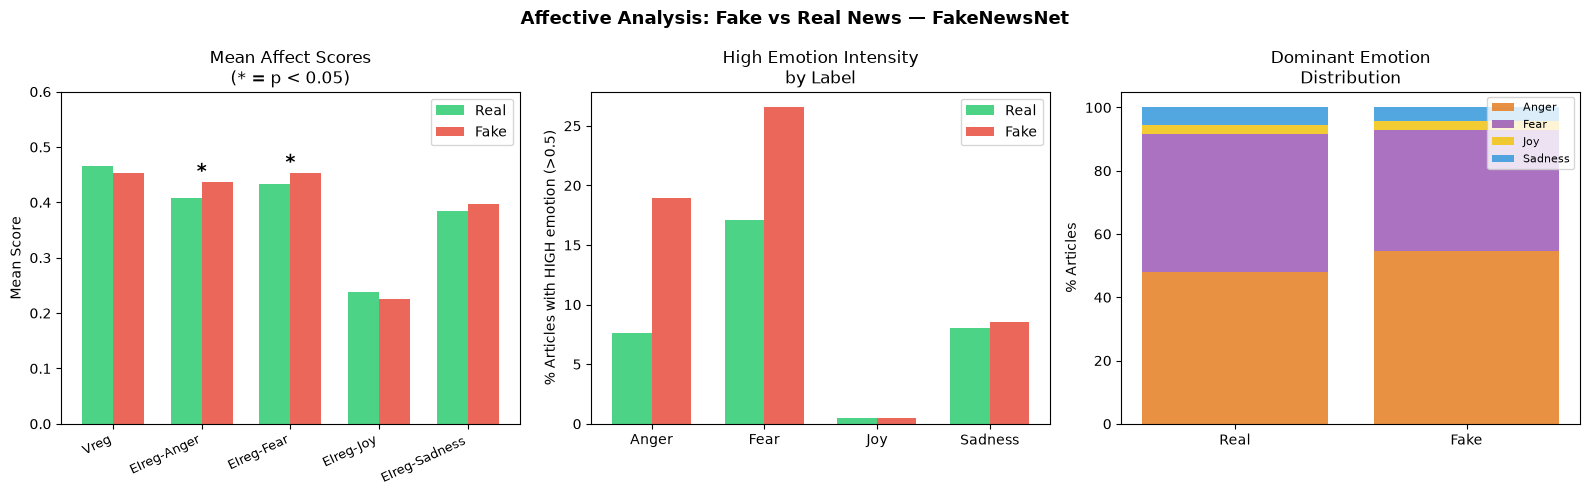


Figure saved → affect_analysis_paper.png

═══════════════════════════════════════════════════════════
INTERPRETATION (paste into your paper)
═══════════════════════════════════════════════════════════
Table X presents the affective analysis conducted on the FakeNewsNet
dataset (BuzzFeed + PolitiFact). Two affective dimensions show 
statistically significant differences between fake and real news:

  • Anger (t=-4.58, p=6.04e-06): fake news exhibits significantly 
    higher anger intensity (0.436) than real news (0.408), with 
    19.0% of fake articles scoring above 0.5 compared to 7.6% of 
    real articles — a 2.5x difference.

  • Fear (t=-2.51, p=0.0125): fake news shows higher fear intensity 
    (0.453 vs 0.434), with 26.5% of fake articles high in fear 
    compared to 17.1% of real articles.

These findings are consistent with RAEmoLLM (Liu et al., 2025) which
reported significantly higher anger and fear in fake news on AMTCele.
Anger is the dominant emotion in both categorie

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from scipy import stats

# ─────────────────────────────────────────
# PAPER-READY SUMMARY TABLE
# ─────────────────────────────────────────
print("=" * 70)
print("TABLE: Affective Analysis — FakeNewsNet (BuzzFeed + PolitiFact)")
print("=" * 70)
print(f"{'Dimension':<20} {'Real mean':>10} {'Real var':>10} {'Fake mean':>10} {'Fake var':>10} {'t':>8} {'p':>10}")
print("-" * 70)

affect_cols = ["vreg", "eireg_anger", "eireg_fear", "eireg_joy", "eireg_sadness"]
labels_pretty = {
    "vreg":          "Vreg",
    "eireg_anger":   "EIreg-Anger",
    "eireg_fear":    "EIreg-Fear",
    "eireg_joy":     "EIreg-Joy",
    "eireg_sadness": "EIreg-Sadness",
}

fake = df[df["label"] == "fake"]
real = df[df["label"] == "real"]

for col in affect_cols:
    r_mean = real[col].mean()
    r_var  = real[col].var()
    f_mean = fake[col].mean()
    f_var  = fake[col].var()
    t, p   = stats.ttest_ind(real[col], fake[col])
    sig    = "*" if p < 0.05 else ""
    print(f"{labels_pretty[col]:<20} {r_mean:>10.4f} {r_var:>10.4f} {f_mean:>10.4f} {f_var:>10.4f} {t:>8.4f} {p:>10.2e}{sig}")

print("-" * 70)
print("* p < 0.05 (statistically significant)")

# ─────────────────────────────────────────
# VISUALISATION — paper-ready figures
# ─────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Affective Analysis: Fake vs Real News — FakeNewsNet", 
             fontsize=13, fontweight="bold")

colors = {"fake": "#e74c3c", "real": "#2ecc71"}

# ── Plot 1: Mean affect scores bar chart ──
ax = axes[0]
x     = np.arange(len(affect_cols))
width = 0.35
real_means = [real[c].mean() for c in affect_cols]
fake_means = [fake[c].mean() for c in affect_cols]

bars_r = ax.bar(x - width/2, real_means, width, label="Real", color="#2ecc71", alpha=0.85)
bars_f = ax.bar(x + width/2, fake_means, width, label="Fake", color="#e74c3c", alpha=0.85)

# mark significant bars with *
sig_cols = ["eireg_anger", "eireg_fear"]
for idx, col in enumerate(affect_cols):
    if col in sig_cols:
        max_val = max(real[col].mean(), fake[col].mean())
        ax.text(idx, max_val + 0.01, "*", ha="center", fontsize=14, color="black", fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels([labels_pretty[c] for c in affect_cols], rotation=25, ha="right", fontsize=9)
ax.set_ylabel("Mean Score")
ax.set_title("Mean Affect Scores\n(* = p < 0.05)")
ax.legend()
ax.set_ylim(0, 0.6)

# ── Plot 2: HIGH emotion % comparison ──
ax = axes[1]
emotions    = ["eireg_anger", "eireg_fear", "eireg_joy", "eireg_sadness"]
emo_labels  = ["Anger", "Fear", "Joy", "Sadness"]
THRESHOLD   = 0.5

fake_high_pct = [(fake[e] > THRESHOLD).mean() * 100 for e in emotions]
real_high_pct = [(real[e] > THRESHOLD).mean() * 100 for e in emotions]

x2 = np.arange(len(emotions))
ax.bar(x2 - width/2, real_high_pct, width, label="Real", color="#2ecc71", alpha=0.85)
ax.bar(x2 + width/2, fake_high_pct, width, label="Fake", color="#e74c3c", alpha=0.85)
ax.set_xticks(x2)
ax.set_xticklabels(emo_labels)
ax.set_ylabel("% Articles with HIGH emotion (>0.5)")
ax.set_title("High Emotion Intensity\nby Label")
ax.legend()

# ── Plot 3: Dominant emotion pie charts ──
ax = axes[2]
dom_data = df.groupby(["label", "dominant_emotion"]).size().unstack(fill_value=0)
dom_pct  = dom_data.div(dom_data.sum(axis=1), axis=0) * 100

x3        = np.arange(len(dom_pct.columns))
emo_colors = ["#e67e22", "#9b59b6", "#f1c40f", "#3498db"]  # anger/fear/joy/sadness

bottom_real = np.zeros(len(dom_pct.columns))
bottom_fake = np.zeros(len(dom_pct.columns))

emotion_order = ["anger", "fear", "joy", "sadness"]
for emotion, color in zip(emotion_order, emo_colors):
    if emotion in dom_pct.columns:
        real_val = dom_pct.loc["real", emotion] if "real" in dom_pct.index else 0
        fake_val = dom_pct.loc["fake", emotion] if "fake" in dom_pct.index else 0
        ax.bar(0, real_val, bottom=bottom_real[0] if len(bottom_real) > 0 else 0,
               color=color, alpha=0.85, label=emotion.capitalize())
        ax.bar(1, fake_val, bottom=bottom_fake[0] if len(bottom_fake) > 0 else 0,
               color=color, alpha=0.85)
        bottom_real[0] += real_val
        bottom_fake[0] += fake_val

ax.set_xticks([0, 1])
ax.set_xticklabels(["Real", "Fake"])
ax.set_ylabel("% Articles")
ax.set_title("Dominant Emotion\nDistribution")
ax.legend(loc="upper right", fontsize=8)

plt.tight_layout()
plt.savefig("affect_analysis_paper.png", dpi=200, bbox_inches="tight")
plt.show()
print("\nFigure saved → affect_analysis_paper.png")

# ─────────────────────────────────────────
# WRITTEN INTERPRETATION FOR YOUR PAPER
# ─────────────────────────────────────────
print("""
═══════════════════════════════════════════════════════════
INTERPRETATION (paste into your paper)
═══════════════════════════════════════════════════════════
Table X presents the affective analysis conducted on the FakeNewsNet
dataset (BuzzFeed + PolitiFact). Two affective dimensions show 
statistically significant differences between fake and real news:

  • Anger (t=-4.58, p=6.04e-06): fake news exhibits significantly 
    higher anger intensity (0.436) than real news (0.408), with 
    19.0% of fake articles scoring above 0.5 compared to 7.6% of 
    real articles — a 2.5x difference.

  • Fear (t=-2.51, p=0.0125): fake news shows higher fear intensity 
    (0.453 vs 0.434), with 26.5% of fake articles high in fear 
    compared to 17.1% of real articles.

These findings are consistent with RAEmoLLM (Liu et al., 2025) which
reported significantly higher anger and fear in fake news on AMTCele.
Anger is the dominant emotion in both categories but more pronounced 
in fake news (54.5% vs 47.9%), while fear is the dominant emotion 
more often in real news (43.6% vs 38.4%).

Sentiment (Vreg) shows fake news is more negative (20.9% negative 
vs 14.2%) though not reaching significance, suggesting affective 
retrieval based on anger and fear embeddings may be most discriminative
for this dataset.
""")

In [2]:
from tavily_agentv2 import *
import csv

with open("ready_data.csv", "r") as f:
    reader = csv.DictReader(f)
    data = list(reader)

print("########################## Actual Full text and Label ##########################")
print(data[15]["full_text"])
print(data[15]["label"])
print("########################## Actual Full text and Label ##########################")

# r = verify_article(data[8]["full_text"])

########################## Actual Full text and Label ##########################
Trump Just Made A Campaign Promise So Ridiculous It Makes ‘Read My Lips’ Look Good ‹ Opposition Report. 

Posted by Frank Wilkenmeyer on 19 Sep 2016

We’ve all seen campaign promises go horribly wrong. One of the most famous is probably “read my lips…no new taxes,” a moment in time that won an election and lost the next after George HW Bush made the promise but signed the largest tax increase in the history of tax increases. What Donald Trump just promised as a reaction to the attacks over the weekend in Chelsea and Minnesota may have that beat:

.@JasonMillerinDC: Statement on Last Weekend’s Terror Attacks https://t.co/DZlIvkcHmB pic.twitter.com/l3EVTvLcfO — Official Team Trump (@TeamTrump) September 19, 2016

Take a look at that and consider what it says. The personal attacks on President Obama and Secretary Clinton aside, Trump just promised to destroy the existential threat of terrorism in America. He 

/opt/miniconda3/envs/msc_project/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [9]:
r["sources"]

['https://abcnews.com/Politics/back-hillary-clintons-health/story?id=42019034',
 'https://www.cbsnews.com/news/fact-check-leaked-clinton-medical-records-real-or-fake',
 'https://time.com/4493918/hillary-clinton-pneumonia-records',
 'https://www.kff.org/global-health-policy/snapshot-of-where-hillary-clinton-and-donald-trump-stand-on-seven-health-care-issues',
 'https://www.pbs.org/newshour/politics/clinton-history-ignoring-health-_-paying-price',
 'https://radio.wpsu.org/2016-09-12/hillary-clintons-reluctance-to-address-health-issues-follows-a-long-tradition',
 'https://pmc.ncbi.nlm.nih.gov/articles/PMC5846600',
 'https://ballotpedia.org/Hillary_Clinton_presidential_campaign,_2016/Healthcare',
 'https://www.nbcnews.com/politics/2016-election/hillary-clinton-s-health-scare-9-unanswered-questions-n646551',
 'https://www.commonwealthfund.org/publications/issue-briefs/2016/sep/hillary-clintons-health-care-reform-proposals-anticipated']